In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.regressionplots import influence_plot
import statsmodels.formula.api as smf


In [5]:
# reading the data
df = pd.read_csv('/Users/furkhanansari/Desktop/Data Science/DataSets/Toyoto_Corrola.csv')
df

,Id,Model,Price,Age_08_04,KM,HP,Doors,Cylinders,Gears,Weight
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,46986,90,3,4,5,1165
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,72937,90,3,4,5,1165
2,3,ÊTOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,41711,90,3,4,5,1165
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,48000,90,3,4,5,1165
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,38500,90,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...
1431,1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,20544,86,3,4,5,1025
1432,1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,19000,86,3,4,5,1015
1433,1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,17016,86,3,4,5,1015
1434,1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,16916,86,3,4,5,1015


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         1436 non-null   int64 
 1   Model      1436 non-null   object
 2   Price      1436 non-null   int64 
 3   Age_08_04  1436 non-null   int64 
 4   KM         1436 non-null   int64 
 5   HP         1436 non-null   int64 
 6   Doors      1436 non-null   int64 
 7   Cylinders  1436 non-null   int64 
 8   Gears      1436 non-null   int64 
 9   Weight     1436 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 112.3+ KB


In [8]:
# dropping the not required cols form the database
df1 = df.drop(columns = ['Id','Model'])
df1

,Price,Age_08_04,KM,HP,Doors,Cylinders,Gears,Weight
0,13500,23,46986,90,3,4,5,1165
1,13750,23,72937,90,3,4,5,1165
2,13950,24,41711,90,3,4,5,1165
3,14950,26,48000,90,3,4,5,1165
4,13750,30,38500,90,3,4,5,1170
...,...,...,...,...,...,...,...,...
1431,7500,69,20544,86,3,4,5,1025
1432,10845,72,19000,86,3,4,5,1015
1433,8500,71,17016,86,3,4,5,1015
1434,7250,70,16916,86,3,4,5,1015


In [19]:
# renaming the age col
df1.rename(columns={'Age_08_04': 'Age'}, inplace=True)

In [20]:
# checking for na values
df1.isna().sum()

Price        0
Age          0
KM           0
HP           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [21]:
df1.describe()

,Price,Age,KM,HP,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,5.000000,4.0,6.000000,1615.00000


In [22]:
df1.dtypes


Price        int64
Age          int64
KM           int64
HP           int64
Doors        int64
Cylinders    int64
Gears        int64
Weight       int64
dtype: object

In [23]:
df1.corr()

,Price,Age,KM,HP,Doors,Cylinders,Gears,Weight
Price,1.000000,-0.876590,-0.569960,0.314990,0.185326,NaN,0.063104,0.581198
Age,-0.876590,1.000000,0.505672,-0.156622,-0.148359,NaN,-0.005364,-0.470253
KM,-0.569960,0.505672,1.000000,-0.333538,-0.036197,NaN,0.015023,-0.028598
HP,0.314990,-0.156622,-0.333538,1.000000,0.092424,NaN,0.209477,0.089614
Doors,0.185326,-0.148359,-0.036197,0.092424,1.000000,NaN,-0.160141,0.302618
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,0.063104,-0.005364,0.015023,0.209477,-0.160141,NaN,1.000000,0.020613
Weight,0.581198,-0.470253,-0.028598,0.089614,0.302618,NaN,0.020613,1.000000


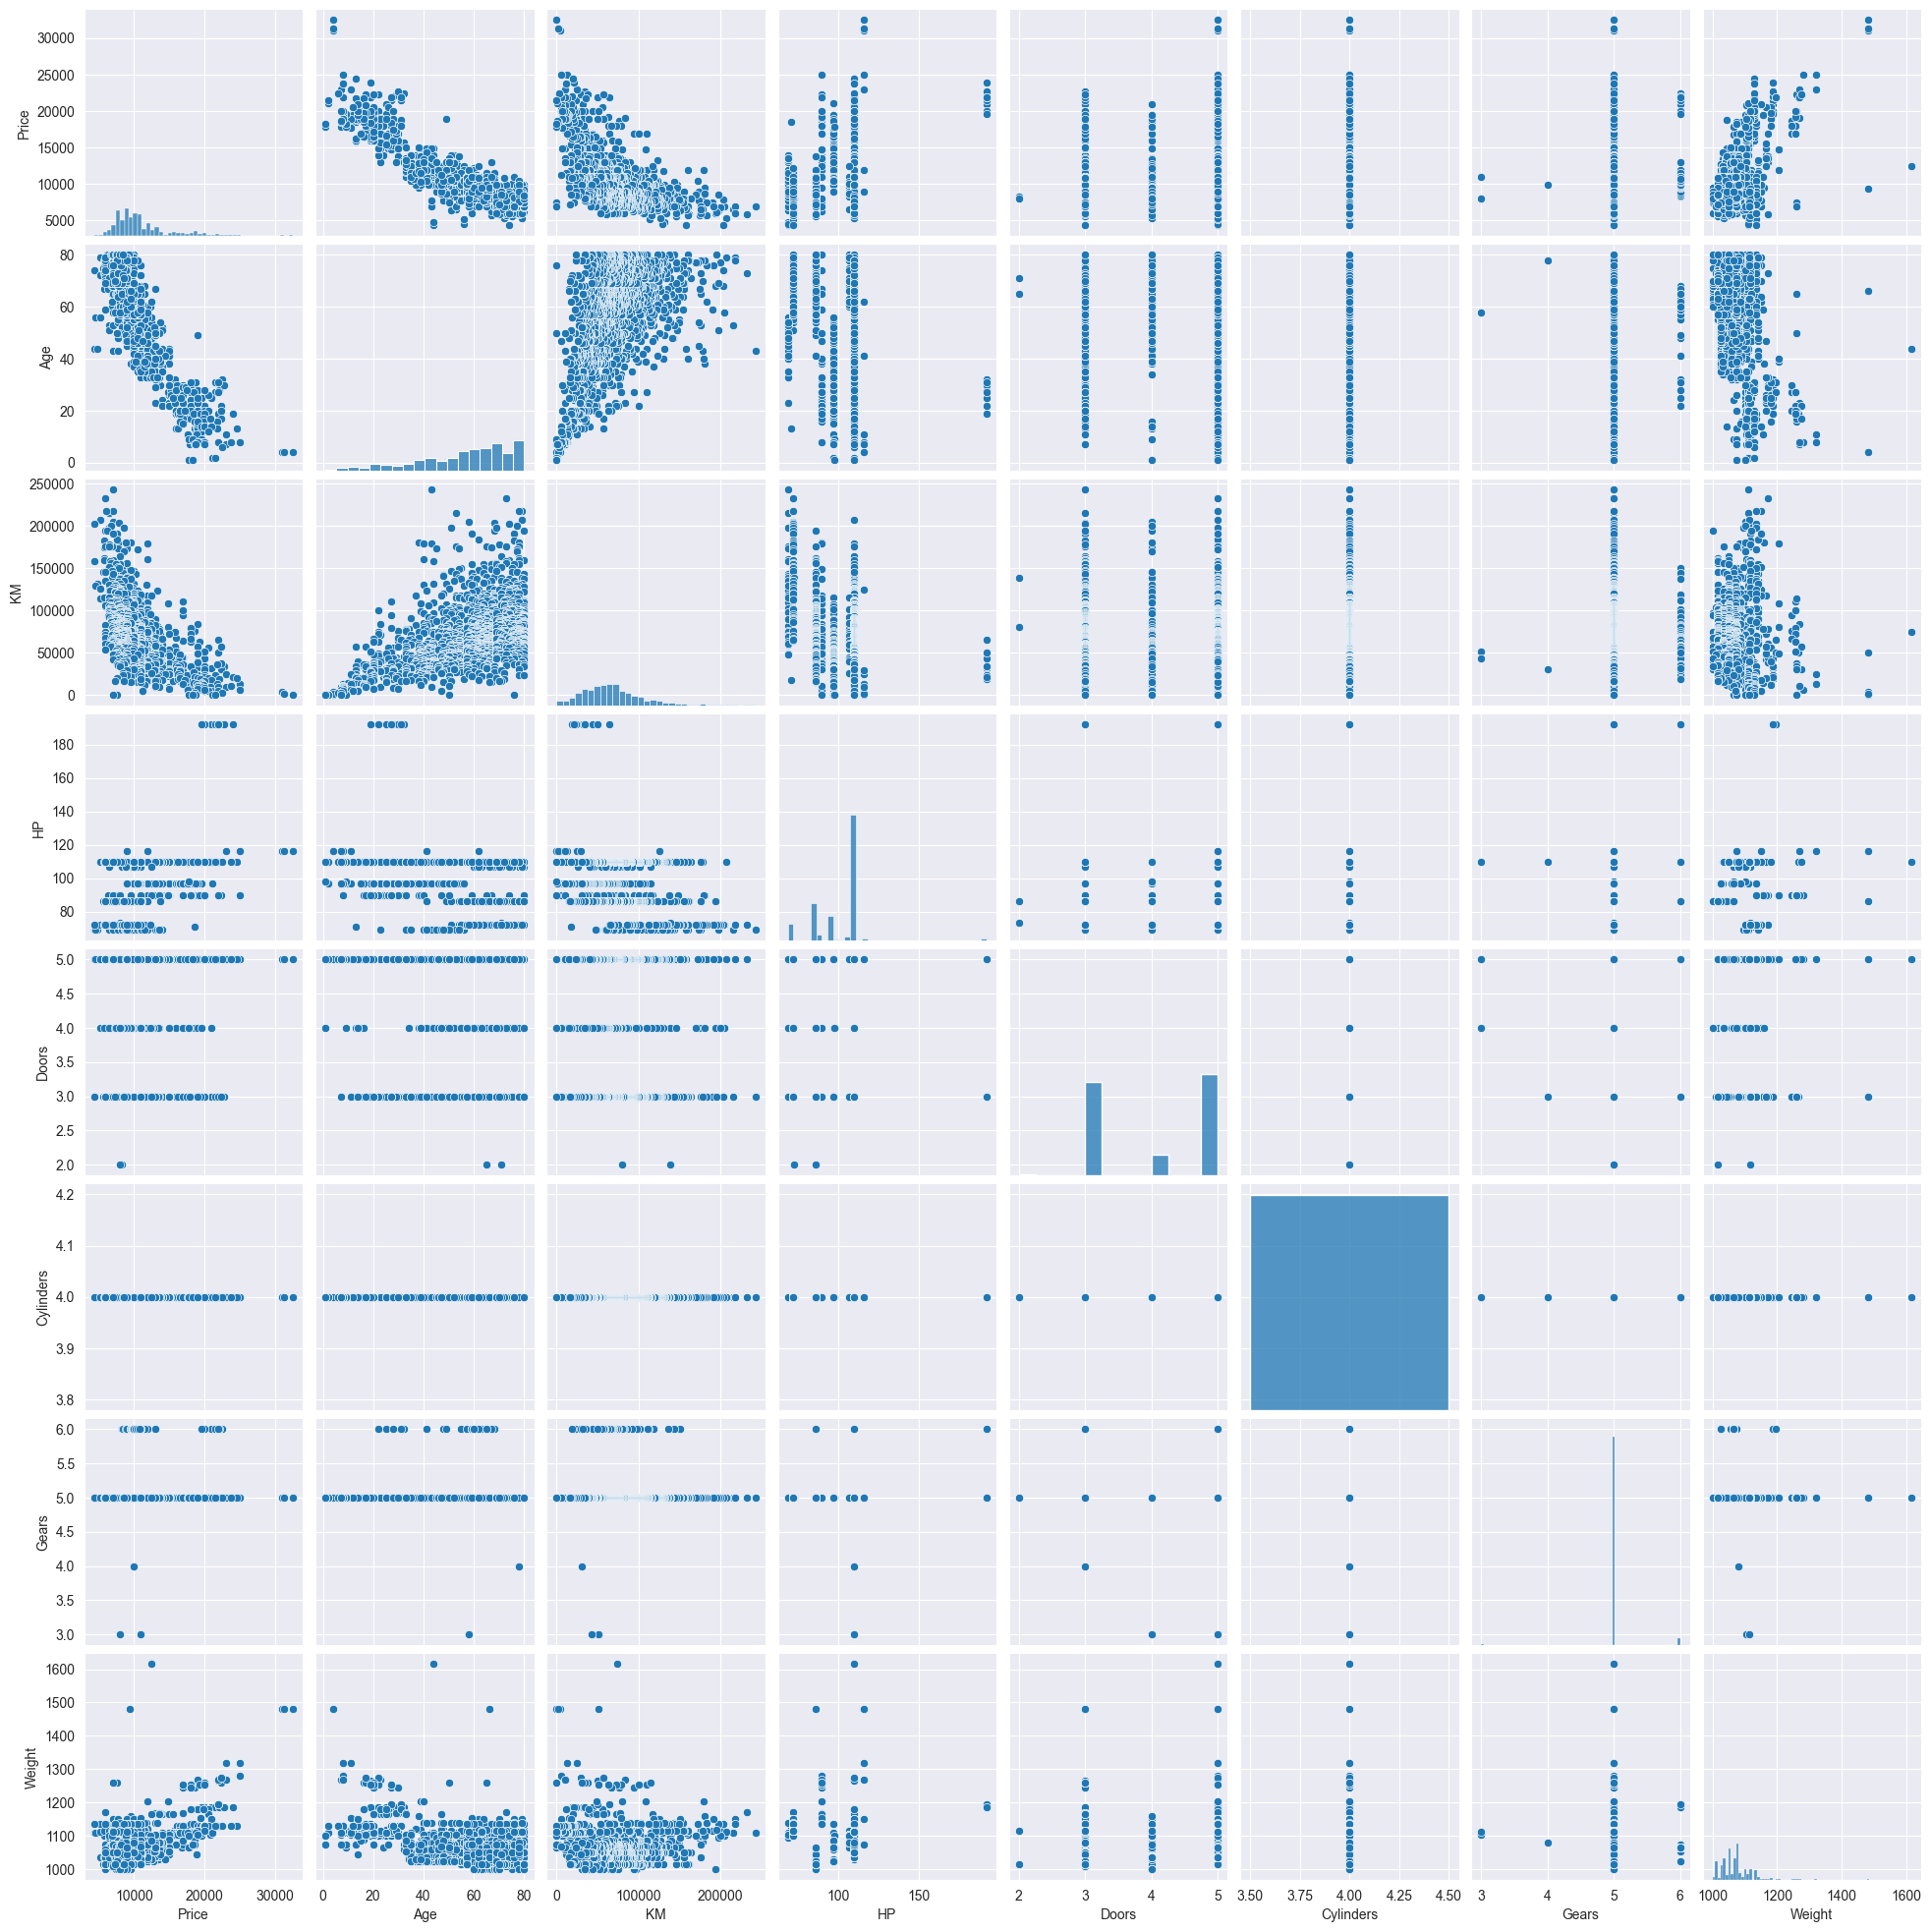

In [24]:
# scatter plot along with tht histogams for all the variables
sns.set_style(style = 'darkgrid')
sns.pairplot(df1)

In [26]:
# perparing the model
# building the model
model = smf.ols('Price~Age+KM+HP+Doors+Cylinders+Gears+Weight' , data = df1).fit()      


In [27]:
# coefficients
model.params

Intercept    -410.845504
Age          -122.242218
KM             -0.019994
HP             28.350149
Doors          -9.680229
Cylinders   -1643.382016
Gears         622.282925
Weight         18.609651
dtype: float64

In [28]:
# t and p values
print( model.tvalues ,'\n',model.pvalues)
# here the cylinders vlaues are constant we can drop that col

Intercept    -5.323309
Age         -46.728942
KM          -16.542560
HP           10.842418
Doors        -0.242055
Cylinders    -5.323309
Gears         3.152234
Weight       22.446903
dtype: float64 
 Intercept     1.181900e-07
Age          4.387432e-290
KM            2.238900e-56
HP            2.231791e-26
Doors         8.087723e-01
Cylinders     1.181900e-07
Gears         1.653931e-03
Weight        7.856458e-96
dtype: float64


In [29]:
# r squred vlaues and adj r squared values 
(model.rsquared , model.rsquared_adj)

(np.float64(0.8628024511073658), np.float64(0.8622263942190832))

In [31]:
m1_D = smf.ols('Price~Doors',data = df1).fit()
print( m1_D.tvalues ,'\n',m1_D.pvalues)

Intercept    19.258097
Doors         7.141657
dtype: float64 
 Intercept    1.094732e-73
Doors        1.461237e-12
dtype: float64


In [33]:
# calculating vif
rsq_age = smf.ols('Age~KM+HP+Doors+Cylinders+Gears+Weight',data = df1).fit().rsquared
vif_age = 1/(1-rsq_age)

rsq_KM = smf.ols('KM~Age+HP+Doors+Cylinders+Gears+Weight',data = df1).fit().rsquared
vif_KM = 1/(1-rsq_KM)

rsq_HP = smf.ols('HP~Age+KM+Doors+Cylinders+Gears+Weight',data = df1).fit().rsquared
vif_HP = 1/(1-rsq_HP)

rsq_Doors = smf.ols('Doors~Age+KM+HP+Cylinders+Gears+Weight',data = df1).fit().rsquared
vif_Doors = 1/(1-rsq_Doors)

rsq_Cylinders = smf.ols('Cylinders~Age+KM+HP+Doors+Gears+Weight',data = df1).fit().rsquared
vif_Cylinders = 1/(1-rsq_Cylinders)

rsq_Gears = smf.ols('Gears~Age+KM+HP+Doors+Cylinders+Weight',data = df1).fit().rsquared
vif_Gears = 1/(1-rsq_Gears)

rsq_Weight = smf.ols('Weight~Age+KM+HP+Doors+Cylinders+Gears',data = df1).fit().rsquared
vif_Weight = 1/(1-rsq_Weight)

# soritng vif values in a dataframe

d1 = {'Variables':['Age','KM','HP','Doors','Cylinders','Gears','Weight'],'VIF':[vif_age,vif_KM,vif_HP,vif_Doors,vif_Cylinders,vif_Gears,vif_Weight ]}
Vif_frame = pd.DataFrame(d1)
Vif_frame


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,Variables,VIF
0,Age,1.874542
1,KM,1.627039
2,HP,1.214909
3,Doors,1.149301
4,Cylinders,0.000000
5,Gears,1.096501
6,Weight,1.508041


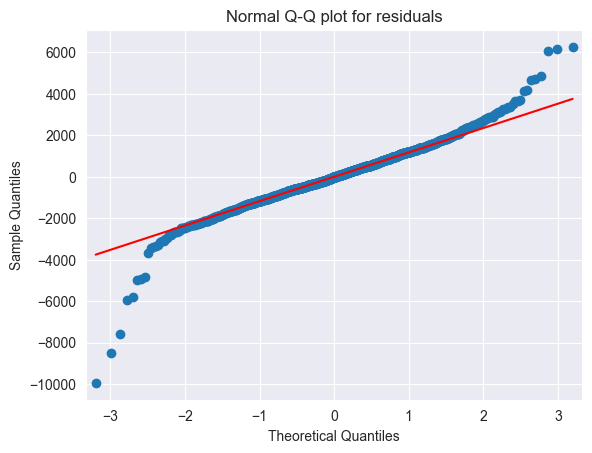

In [34]:
# residual analysis
import statsmodels.api as sm
qqplot = sm.qqplot(model.resid,line='q')
plt.title('Normal Q-Q plot for residuals')
plt.show()

In [37]:
list(np.where(model.resid > 5000))

[array([109, 147, 523])]

In [38]:
# standardize the dataset
def get_standardized_values(vals):
    return (vals-vals.mean()) / vals.std()

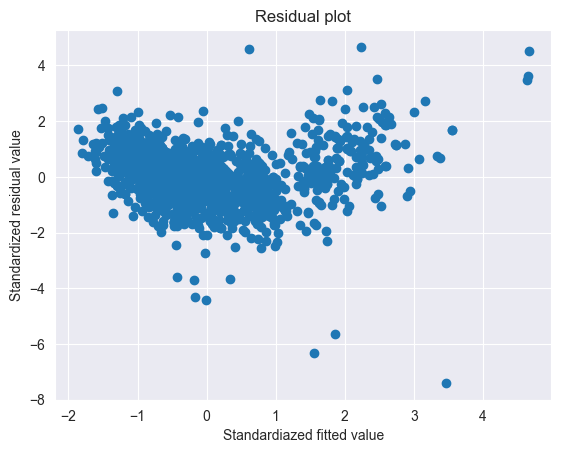

In [40]:
plt.scatter(get_standardized_values(model.fittedvalues),get_standardized_values(model.resid))
plt.title('Residual plot')
plt.xlabel('Standardiazed fitted value')
plt.ylabel('Standardized residual value')
plt.show()

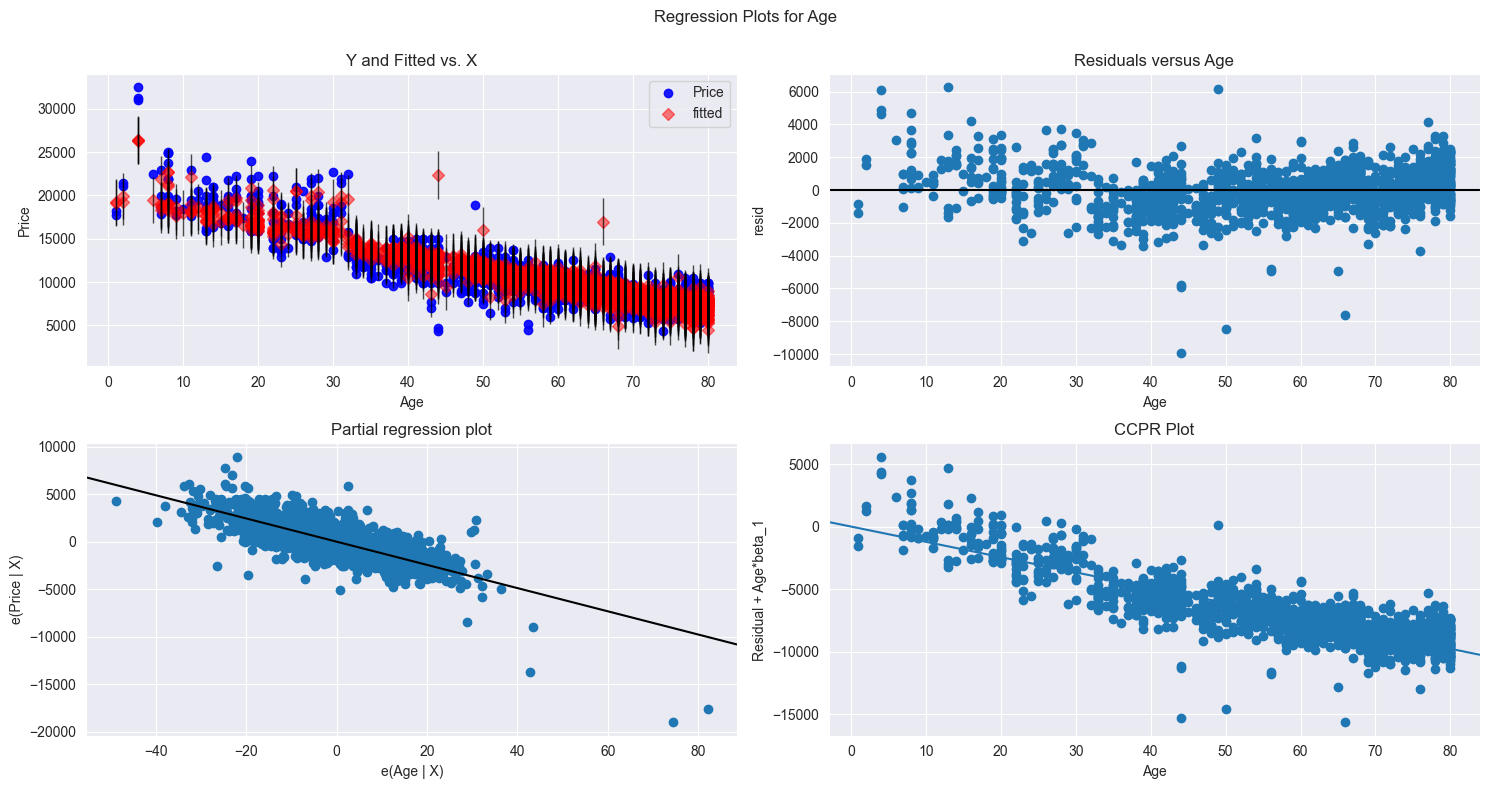

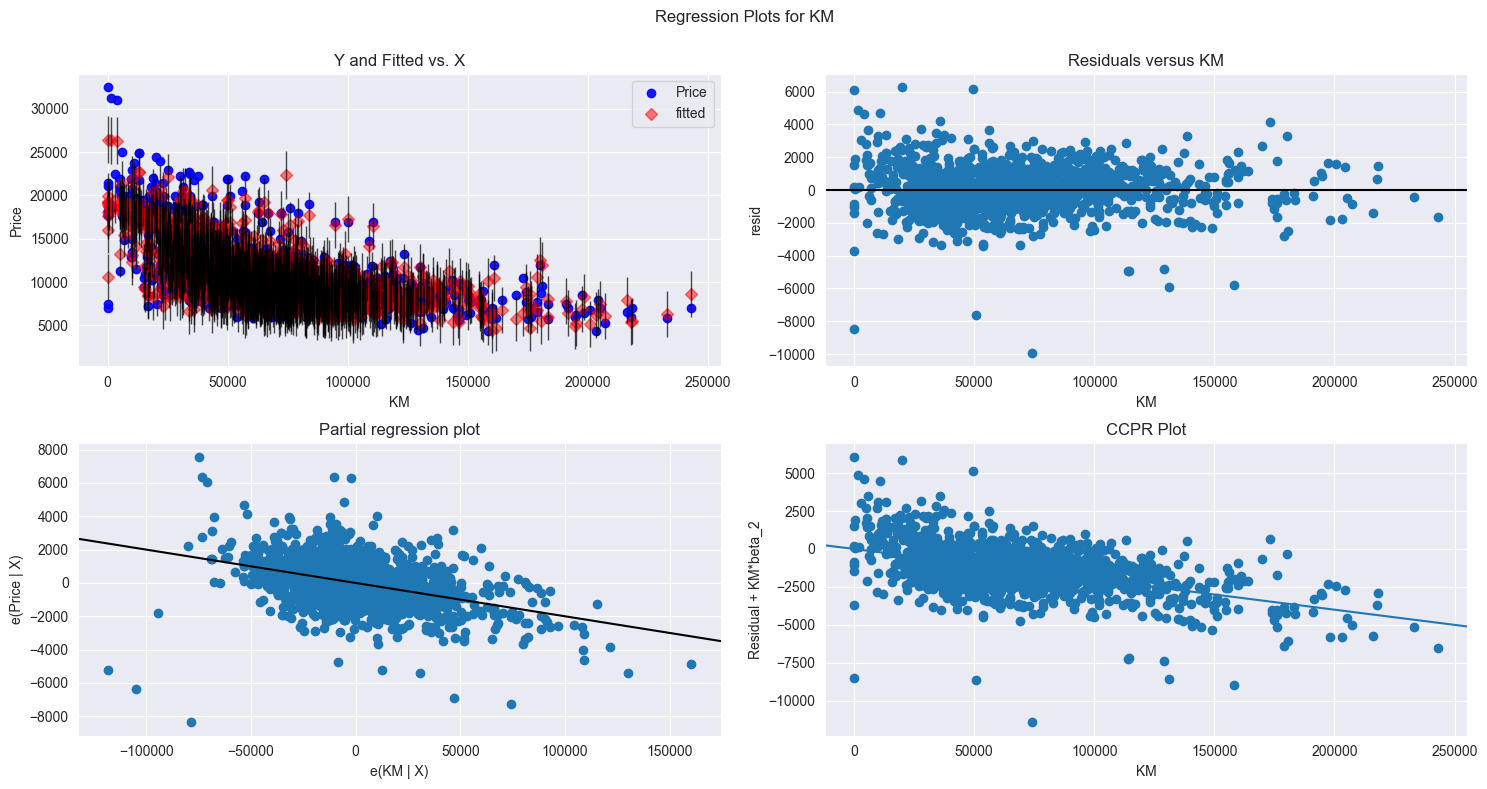

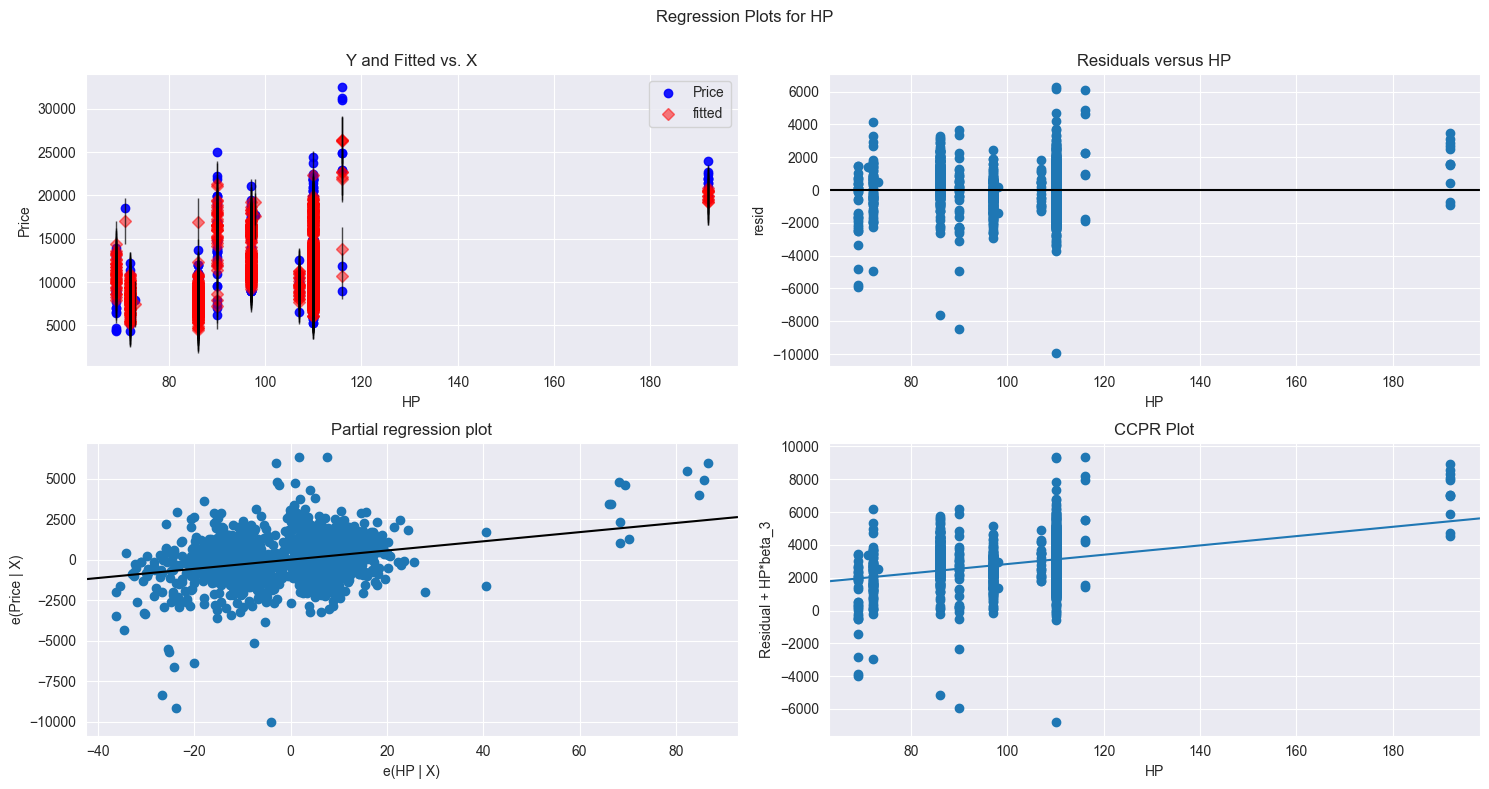

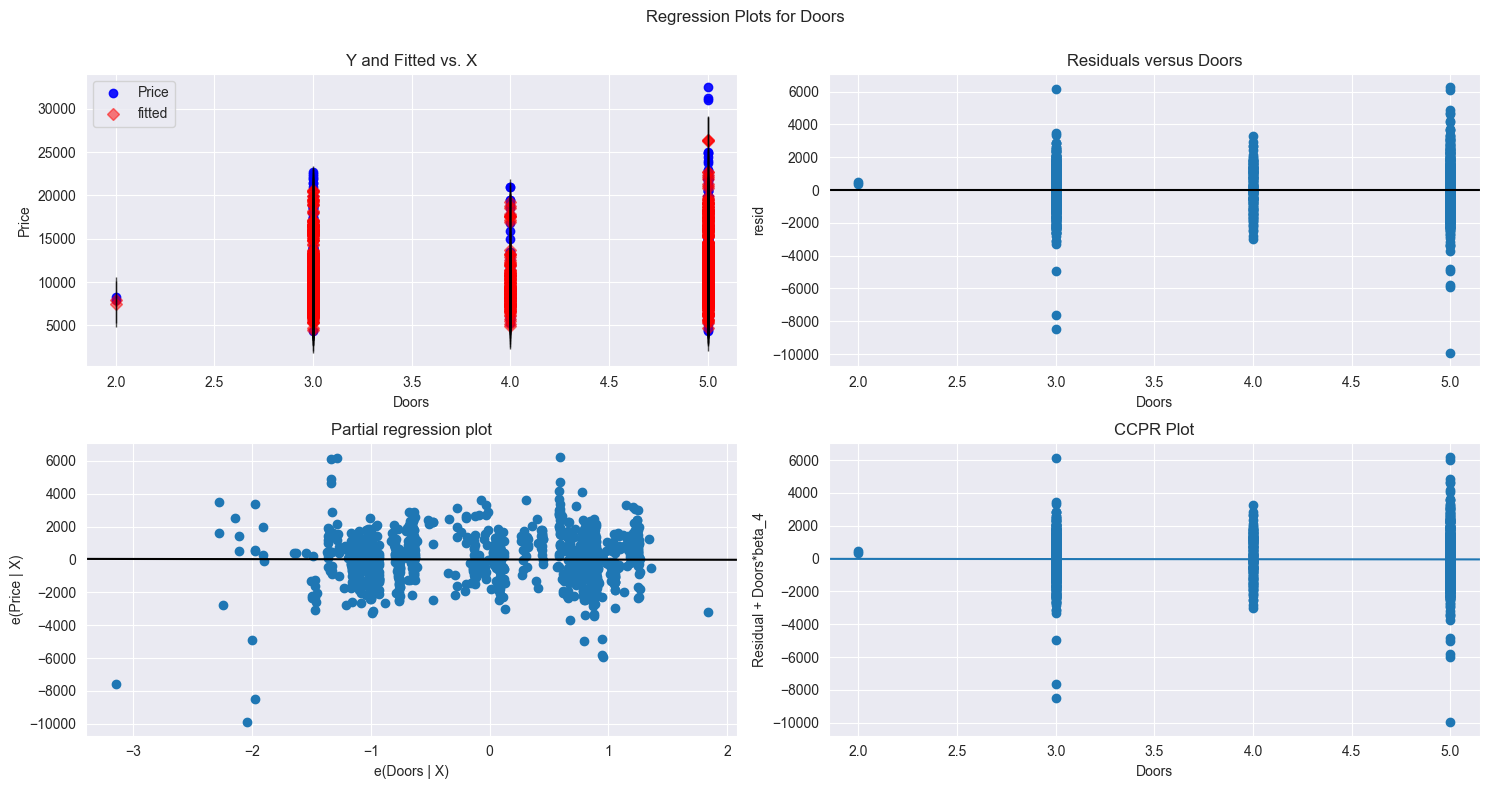

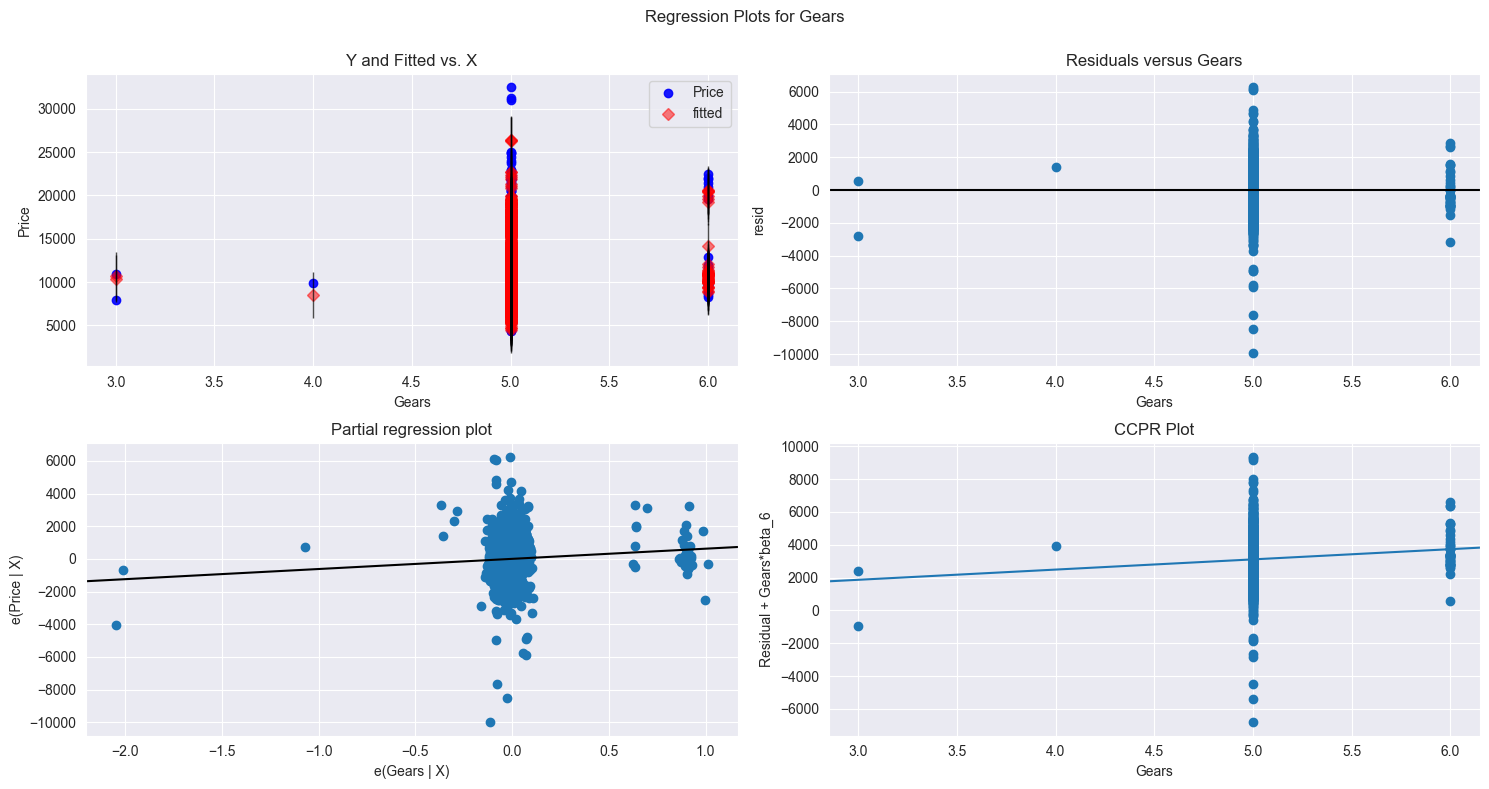

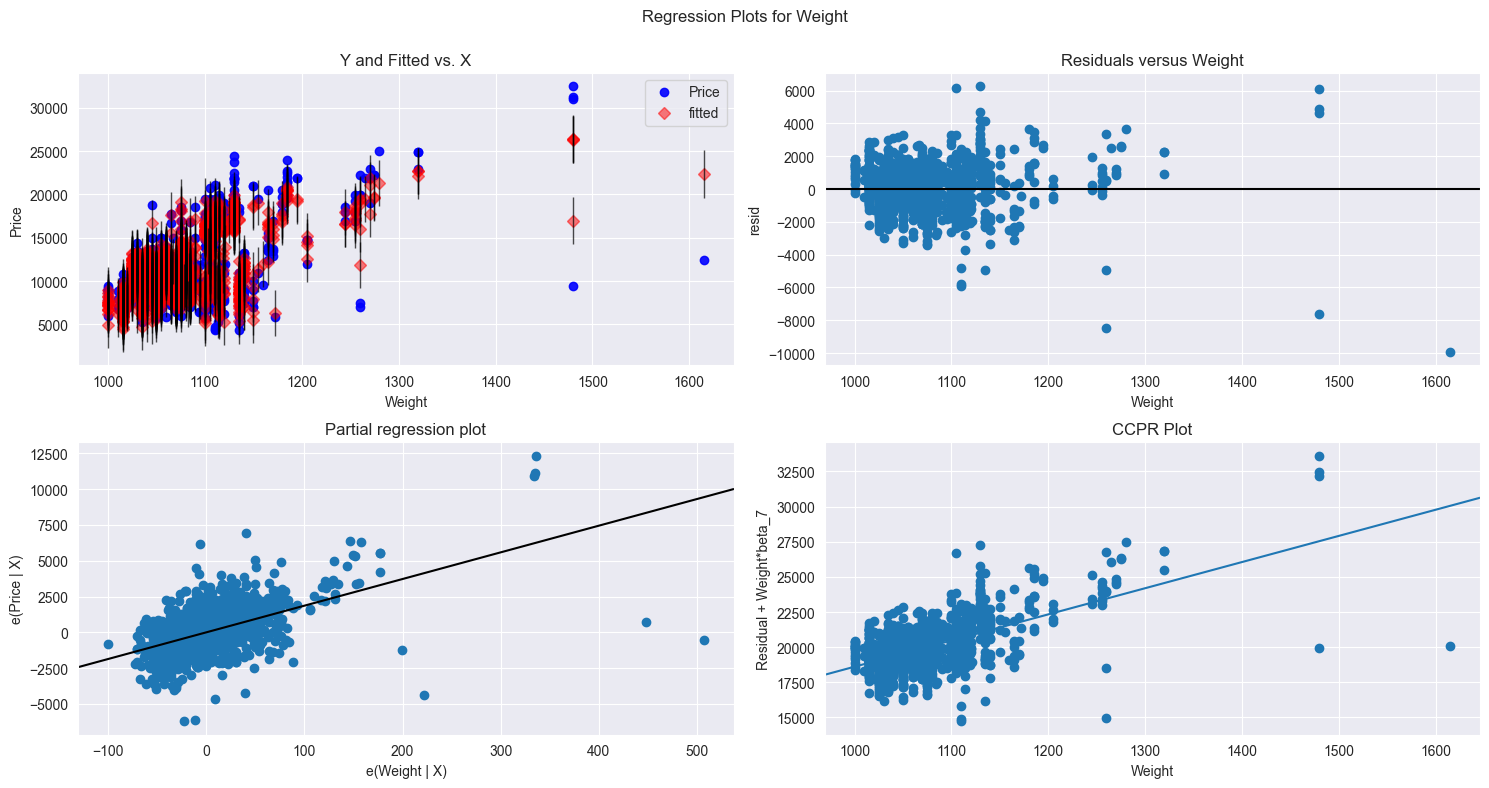

In [45]:
# Residual(ei) vs Regressors(indipendent variable)
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(model, 'Age' , fig = fig)
plt.show()
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(model, 'KM' , fig = fig)
plt.show()
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(model, 'HP' , fig = fig)
plt.show()
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(model, 'Doors' , fig = fig)
plt.show()
# fig = plt.figure(figsize=(15,8))
# fig = sm.graphics.plot_regress_exog(model, 'Cylinders' , fig = fig)
# plt.show()
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(model, 'Gears' , fig = fig)
plt.show()
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(model, 'Weight' , fig = fig)
plt.show()


In [48]:
# Model Deletion Diagnostics
# Detecting influencers / Outliers
# cook s distance
model_influence = model.get_influence()
(c,_) = model_influence.cooks_distance


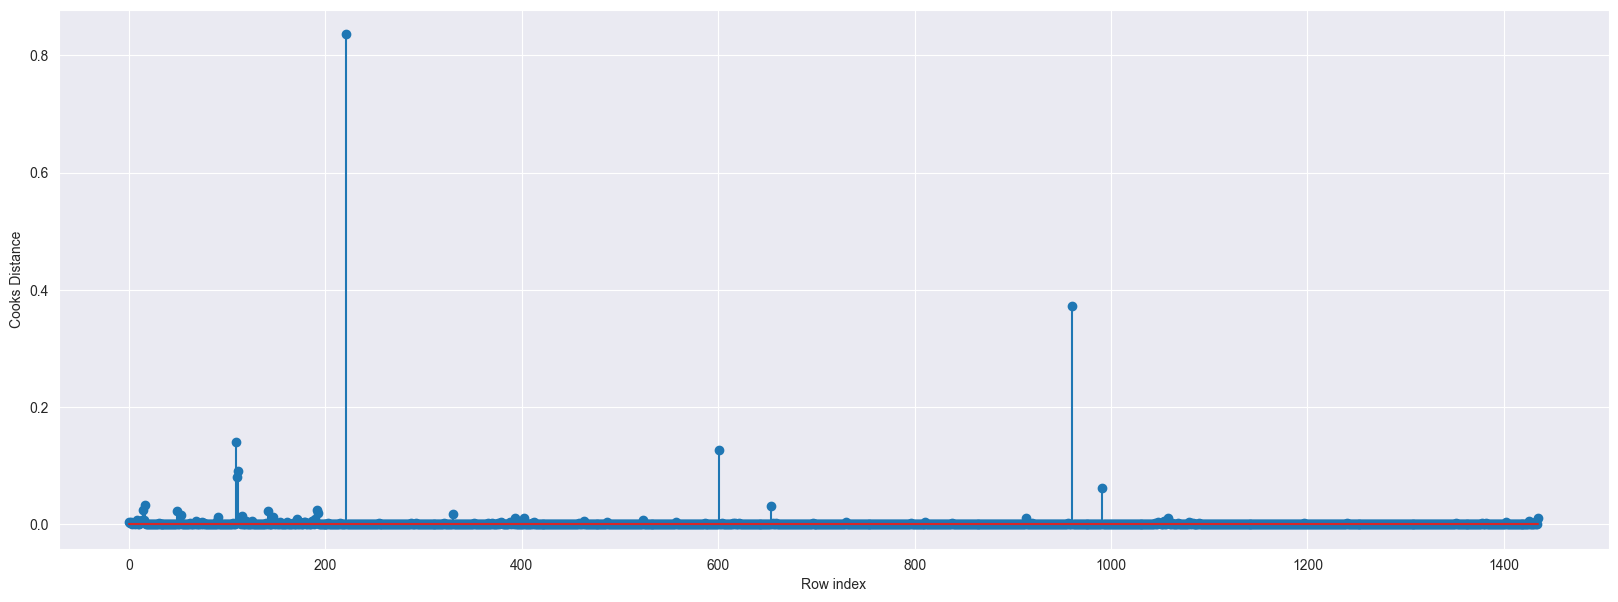

In [51]:
# plot influencers values using stem plot
fig = plt.subplots(figsize=(20,7))
plt.stem(np.arange(len(df1)),np.round(c,3))
plt.xlabel('Row index')
plt.ylabel('Cooks Distance')
plt.show()

In [52]:
# index ans vlaues of influencers weher c is more than .5 
(np.argmax(c),np.max(c))

(np.int64(221), np.float64(0.83590075088546))

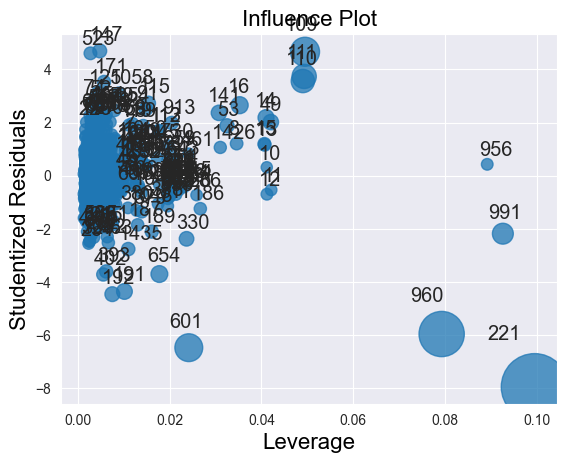

In [54]:
from statsmodels.graphics.regressionplots import influence_plot
influence_plot(model)
plt.show()

In [55]:
k = df1.shape[1]
n = df1.shape[0]
leverage_cutoff = 3 * ((k+1)/n)
leverage_cutoff

0.018802228412256268

In [58]:
df1[df1.index.isin([960,221])]

,Price,Age,KM,HP,Doors,Cylinders,Gears,Weight
221,12450,44,74172,110,5,4,5,1615
960,9390,66,50806,86,3,4,5,1480


In [59]:
df1.head()

,Price,Age,KM,HP,Doors,Cylinders,Gears,Weight
0,13500,23,46986,90,3,4,5,1165
1,13750,23,72937,90,3,4,5,1165
2,13950,24,41711,90,3,4,5,1165
3,14950,26,48000,90,3,4,5,1165
4,13750,30,38500,90,3,4,5,1170


In [60]:
# imporoving the model
df_new = pd.read_csv('/Users/furkhanansari/Desktop/Data Science/DataSets/Toyoto_Corrola.csv')

In [76]:
df2 = df_new.drop(columns = ['Id','Model','Cylinders'])
df2.rename(columns={'Age_08_04': 'Age'}, inplace=True)
df2

,Price,Age,KM,HP,Doors,Gears,Weight
0,13500,23,46986,90,3,5,1165
1,13750,23,72937,90,3,5,1165
2,13950,24,41711,90,3,5,1165
3,14950,26,48000,90,3,5,1165
4,13750,30,38500,90,3,5,1170
...,...,...,...,...,...,...,...
1431,7500,69,20544,86,3,5,1025
1432,10845,72,19000,86,3,5,1015
1433,8500,71,17016,86,3,5,1015
1434,7250,70,16916,86,3,5,1015


In [82]:
df3 = df2.drop(df2.index[[221,960]],axis=0).reset_index()

In [83]:
df3

,index,Price,Age,KM,HP,Doors,Gears,Weight
0,0,13500,23,46986,90,3,5,1165
1,1,13750,23,72937,90,3,5,1165
2,2,13950,24,41711,90,3,5,1165
3,3,14950,26,48000,90,3,5,1165
4,4,13750,30,38500,90,3,5,1170
...,...,...,...,...,...,...,...,...
1429,1431,7500,69,20544,86,3,5,1025
1430,1432,10845,72,19000,86,3,5,1015
1431,1433,8500,71,17016,86,3,5,1015
1432,1434,7250,70,16916,86,3,5,1015


In [84]:
df3 = df3.drop(['index'],axis=1)

In [85]:
df3

,Price,Age,KM,HP,Doors,Gears,Weight
0,13500,23,46986,90,3,5,1165
1,13750,23,72937,90,3,5,1165
2,13950,24,41711,90,3,5,1165
3,14950,26,48000,90,3,5,1165
4,13750,30,38500,90,3,5,1170
...,...,...,...,...,...,...,...
1429,7500,69,20544,86,3,5,1025
1430,10845,72,19000,86,3,5,1015
1431,8500,71,17016,86,3,5,1015
1432,7250,70,16916,86,3,5,1015


In [88]:
# build model
final_m1 = smf.ols('Price~Age+KM+HP+Doors+Gears+Weight',data =df3).fit()



In [91]:
model_influence_m1 = final_m1.get_influence()
(c_m1,_) = model_influence_m1.cooks_distance

Text(0, 0.5, 'Cooks Distance')

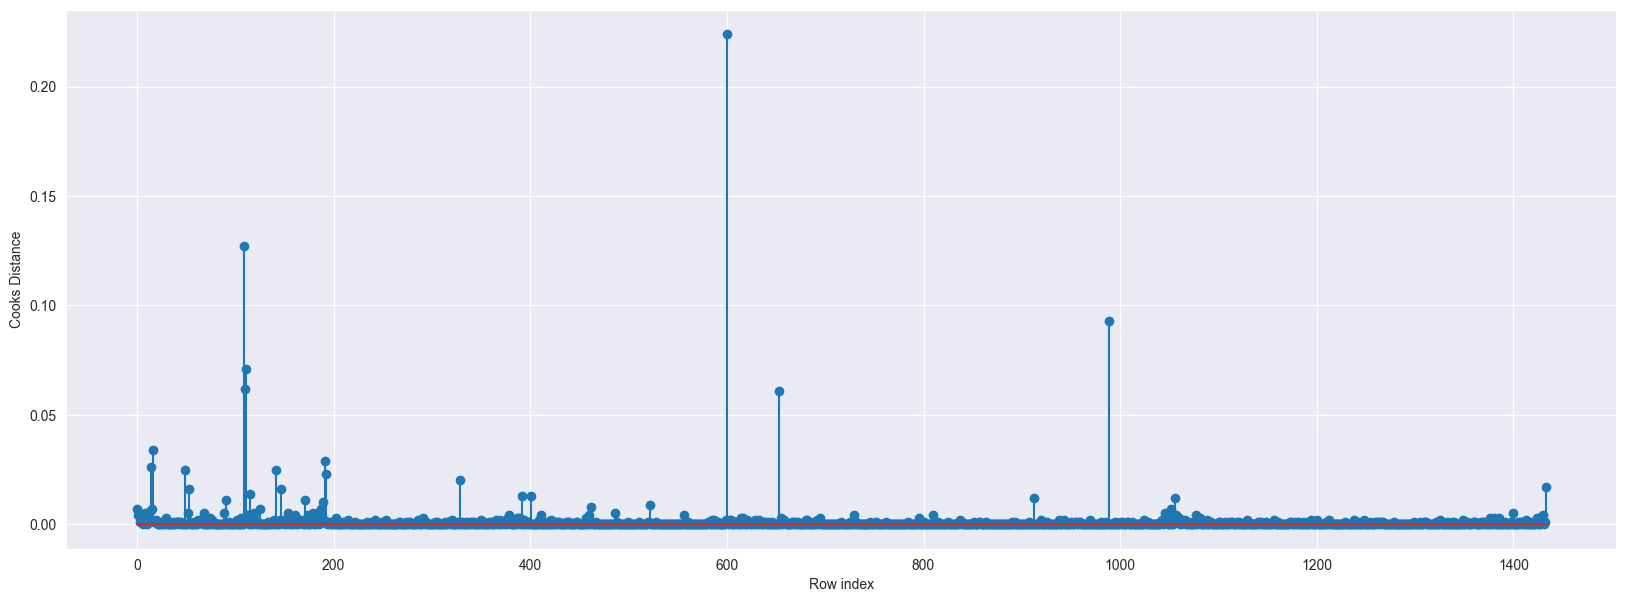

In [92]:
fig = plt.subplots(figsize = (20,7))
plt.stem(np.arange(len(df3)),np.round(c_m1,3))
plt.xlabel('Row index')
plt.ylabel('Cooks Distance')

In [93]:
# index of the data points where c is more than .5
(np.argmax(c_m1),np.max(c_m1))

(np.int64(600), np.float64(0.22365466047019567))

In [94]:
high_cooks_index = np.where(c_m1 > 0.10)[0]
print(high_cooks_index)

[109 600]


In [95]:
df4 = df3.drop(df3.index[[109,600]],axis=0).reset_index()
df4 = df4.drop(['index'],axis=1)

In [96]:
df4

,Price,Age,KM,HP,Doors,Gears,Weight
0,13500,23,46986,90,3,5,1165
1,13750,23,72937,90,3,5,1165
2,13950,24,41711,90,3,5,1165
3,14950,26,48000,90,3,5,1165
4,13750,30,38500,90,3,5,1170
...,...,...,...,...,...,...,...
1427,7500,69,20544,86,3,5,1025
1428,10845,72,19000,86,3,5,1015
1429,8500,71,17016,86,3,5,1015
1430,7250,70,16916,86,3,5,1015


In [97]:
# buliding the model
final_m1 = smf.ols('Price~Age+KM+HP+Doors+Gears+Weight',data =df4).fit()

In [98]:
model_influence_m1 = final_m1.get_influence()
(c_m1,_) = model_influence_m1.cooks_distance

Text(0, 0.5, 'Cooks Distance')

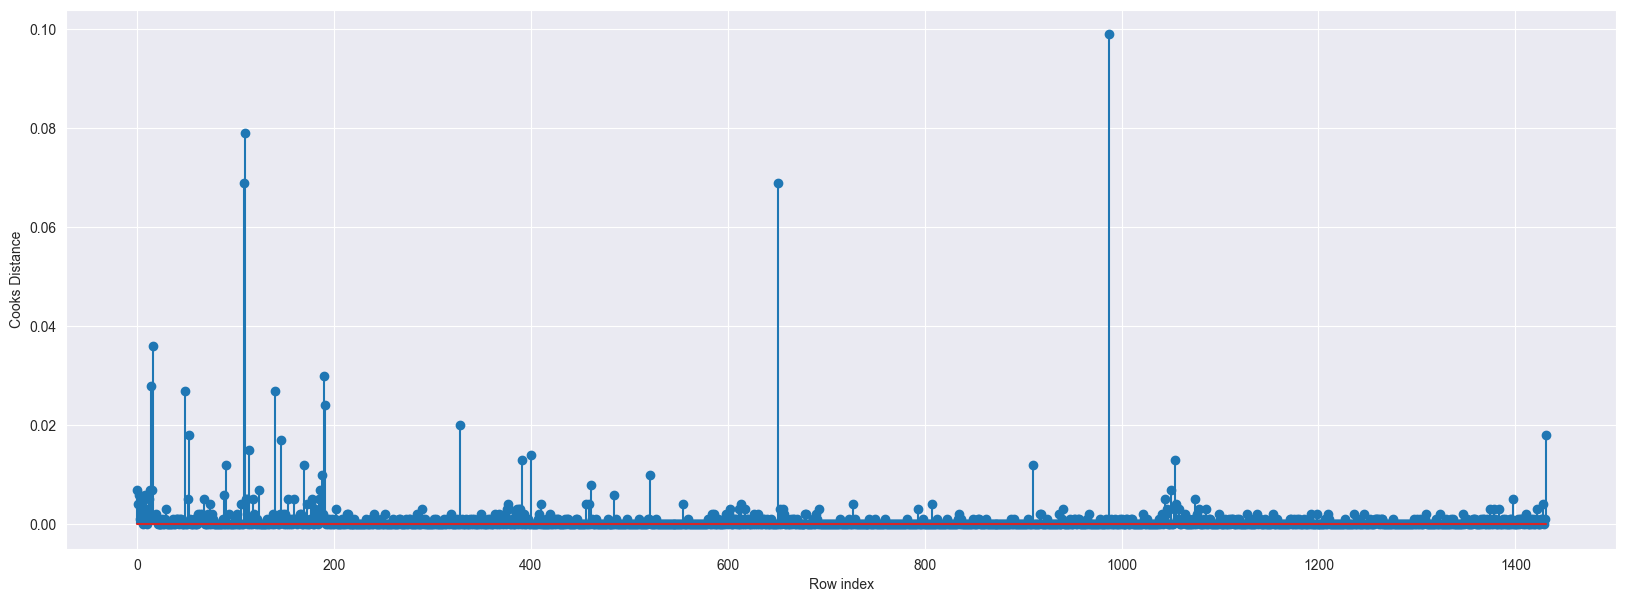

In [99]:
fig = plt.subplots(figsize = (20,7))
plt.stem(np.arange(len(df4)),np.round(c_m1,3))
plt.xlabel('Row index')
plt.ylabel('Cooks Distance')

In [100]:
# index of the data points where c is more than .5
(np.argmax(c_m1),np.max(c_m1))

(np.int64(987), np.float64(0.09871263425659203))

In [101]:
# check the accuray of the model
final_m1 = smf.ols('Price~Age+KM+HP+Doors+Gears+Weight',data =df4).fit()

In [102]:
(final_m1.rsquared , final_m1.aic)

(np.float64(0.8755059597579958), np.float64(24533.435928501447))

In [104]:
# predicting the new data
# new data for prediction
new_data = pd.DataFrame({'Age':40 , 'KM':95,'HP':102,'Doors':4,'Gears':5,'Weight':1200},index =[1])
new_data

,Age,KM,HP,Doors,Gears,Weight
1,40,95,102,4,5,1200


In [105]:
final_m1.predict(new_data)

1    17000.052567
dtype: float64